
--- CCM for Democracy ---

--- CCM for Economy ---

--- CCM for Freedom ---

--- CCM for Liberty ---

--- CCM for democracy_frequency ---

--- CCM for economy_frequency ---

--- CCM for equality_frequency ---

--- CCM for freedom_frequency ---

--- CCM for justice_frequency ---

--- CCM for liberty_frequency ---
                     GDP → Sentiment  Life Expectancy → Sentiment
Democracy                  -0.419329                    -0.387429
Economy                    -0.295499                    -0.282305
Freedom                    -0.199807                    -0.181674
Liberty                    -0.201303                    -0.183733
democracy_frequency         0.859876                     0.859432
economy_frequency           0.720035                     0.723271
equality_frequency         -0.113806                    -0.058449
freedom_frequency           0.088315                     0.099023
justice_frequency          -0.976434                    -0.958613
liberty_frequency        

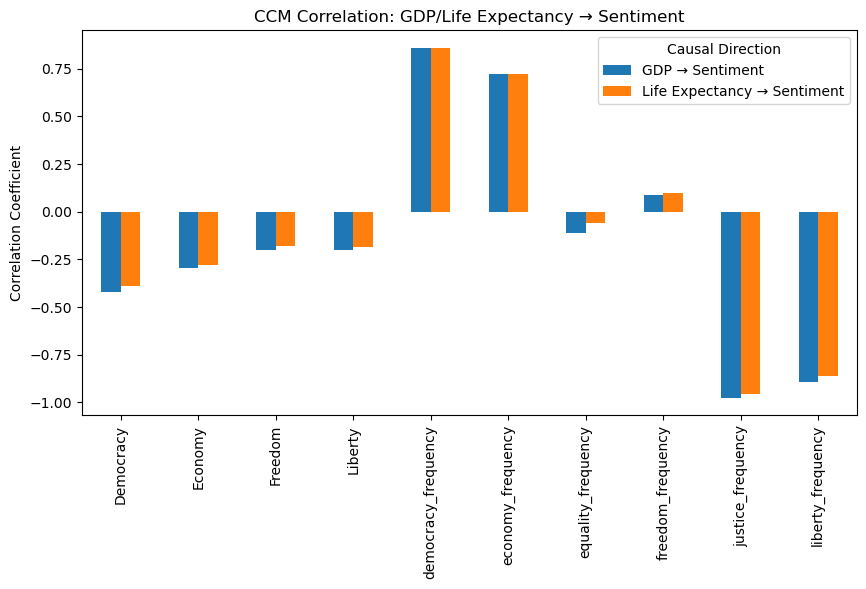

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import pairwise_distances
from scipy.integrate import solve_ivp

# Time-delay embedding
def time_delay_embedding(series, delay, dimension):
    n = len(series)
    embedded = np.zeros((n - (dimension - 1) * delay, dimension))
    for i in range(dimension):
        embedded[:, i] = series[i * delay:n - (dimension - 1 - i) * delay]
    return embedded

# Convergent Cross Mapping (CCM)
def cross_map(source, target, delay, dimension):
    embedded_target = time_delay_embedding(target, delay, dimension)
    predictions = []
    for i in range(len(embedded_target)):
        neighbors = np.argsort(np.linalg.norm(embedded_target - embedded_target[i], axis=1))[:dimension + 1]
        weights = 1 / (np.linalg.norm(embedded_target[neighbors] - embedded_target[i], axis=1) + 1e-10)
        weights /= np.sum(weights)
        prediction = np.sum(weights * source[neighbors])
        predictions.append(prediction)
    return predictions

# Load dataset
df = pd.read_csv("/Users/kylejonespatricia/Documents/Combined_sentiment 1850-1963.csv")  # Ensure the dataset has 'year', 'value', and 'topic' columns

# Convert year to datetime and sort
df['year'] = pd.to_datetime(df['year'], format='%Y')
df = df.sort_values(by='year')

# Pivot table to structure data for time series analysis
df_pivot = df.pivot(index='year', columns='Topic', values='value').dropna()

# Apply CCM to each sentiment topic
ccm_results = {}
for topic in df_pivot.columns:
    if topic in ['gdp_percap', 'Life_expectancy']:
        continue  # Skip economic indicators, only apply to sentiment topics
    print(f"\n--- CCM for {topic} ---")
    predicted_gdp = cross_map(df_pivot['gdp_percap'].values, df_pivot[topic].values, delay=10, dimension=3)
    predicted_life = cross_map(df_pivot['Life_expectancy'].values, df_pivot[topic].values, delay=10, dimension=3)
    
    # Compute correlation between actual and predicted values
    min_length = min(len(df_pivot[topic].values) - 3, len(predicted_gdp))
    ccm_results[topic] = {
        "GDP → Sentiment": np.corrcoef(df_pivot[topic].values[3:3 + min_length], predicted_gdp[:min_length])[0, 1],
        "Life Expectancy → Sentiment": np.corrcoef(df_pivot[topic].values[3:3 + min_length], predicted_life[:min_length])[0, 1]
    }

# Convert CCM results to DataFrame
ccm_df = pd.DataFrame(ccm_results).T
print(ccm_df)

# Save CCM results to file
ccm_df.to_csv("ccm_results.csv")

# Plot CCM correlations
ccm_df.plot(kind='bar', figsize=(10, 5))
plt.title("CCM Correlation: GDP/Life Expectancy → Sentiment")
plt.ylabel("Correlation Coefficient")
plt.legend(title="Causal Direction")
plt.savefig("ccm_results.png")
plt.show()


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests, adfuller, acf, pacf, q_stat
from statsmodels.tsa.arima.model import ARIMA
from sklearn.decomposition import KernelPCA
from sklearn.manifold import TSNE

# Load dataset

# Pivot table to structure data for time series analysis
df_pivot = df.pivot(index='year', columns='Topic', values='value').dropna()

# Ensure year is an integer index
df_pivot.index = df_pivot.index.astype(int)

# Function to perform ADF test for stationarity
def adf_test(series, title):
    result = adfuller(series.dropna())
    print(f'ADF Test for {title}: p-value = {result[1]}')
    return result[1] < 0.05  # Return True if stationary

# Function to test Granger causality
def granger_test(df, target, predictors, max_lag=5):
    test_results = {}
    for predictor in predictors:
        test = grangercausalitytests(df[[target, predictor]], max_lag, verbose=False)
        p_values = [round(test[i+1][0]['ssr_ftest'][1], 4) for i in range(max_lag)]
        test_results[predictor] = p_values
    return pd.DataFrame(test_results, index=[f'Lag {i+1}' for i in range(max_lag)])

# Function to test autocorrelation
def autocorrelation_tests(series, lags=20):
    acf_values = acf(series.dropna(), nlags=lags)
    pacf_values = pacf(series.dropna(), nlags=lags)
    q_stat_values, p_values = q_stat(acf_values[1:], len(series.dropna()))
    return pd.DataFrame({'ACF': acf_values, 'PACF': pacf_values, 'Ljung-Box p': np.append(np.nan, p_values)})

# Function to fit ARIMA model
def fit_arima(series, order=(1, 1, 1)):
    model = ARIMA(series.dropna(), order=order).fit()
    print(model.summary())
    return model

# Apply tests to each topic
for topic in df_pivot.columns:
    print(f"\n--- Analysis for {topic} ---")
    adf_test(df_pivot[topic], topic)
    print("Autocorrelation Results:")
    print(autocorrelation_tests(df_pivot[topic]))
    print("\nFitting ARIMA Model:")
    fit_arima(df_pivot[topic])

# Granger causality tests
gdp_life = pd.read_csv("gdp_life_data.csv").set_index('year')
df_merged = df_pivot.merge(gdp_life, left_index=True, right_index=True, how='inner')

granger_results = {}
for topic in df_pivot.columns:
    print(f"\n--- Granger Causality for {topic} ---")
    granger_results[topic] = granger_test(df_merged, topic, ['GDP_per_capita', 'Life_Expectancy'])

granger_df = pd.concat(granger_results, axis=1)
print(granger_df)

granger_df.to_csv("granger_causality_results.csv")

# Manifold Learning: Extracting nonlinear structure
manifold_data = KernelPCA(n_components=2, kernel='rbf').fit_transform(df_pivot.dropna())
tsne_data = TSNE(n_components=2).fit_transform(df_pivot.dropna())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(manifold_data[:, 0], manifold_data[:, 1], alpha=0.7)
plt.title("Kernel PCA (Nonlinear Projection)")
plt.subplot(1, 2, 2)
plt.scatter(tsne_data[:, 0], tsne_data[:, 1], alpha=0.7)
plt.title("t-SNE Visualization of Sentiment Dynamics")
plt.show()



--- Analysis for Democracy ---
ADF Test for Democracy: p-value = 1.2608396024770615e-11
Autocorrelation Results:
         ACF      PACF  Ljung-Box p
0   1.000000  1.000000          NaN
1   0.305005  0.307728     0.001018
2   0.160365  0.075729     0.001006
3   0.097808  0.034148     0.001873
4   0.153345  0.121647     0.001388
5   0.242042  0.187259     0.000153
6   0.049136 -0.105038     0.000330
7   0.095061  0.073645     0.000466
8  -0.000743 -0.074831     0.000975
9   0.046922  0.015677     0.001715
10  0.141882  0.122680     0.001245
11  0.068932  0.002986     0.001825
12  0.026263 -0.048822     0.003101
13 -0.064643 -0.068542     0.004348
14  0.060331  0.081954     0.006070
15  0.140979  0.106943     0.004193
16  0.076367  0.006211     0.005210
17 -0.037432 -0.113873     0.007622
18 -0.106695 -0.093741     0.007306
19 -0.072579 -0.087892     0.008875
20 -0.038981 -0.038793     0.012289

Fitting ARIMA Model:
                               SARIMAX Results                          

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  

                                SARIMAX Results                                
Dep. Variable:     democracy_frequency   No. Observations:                  113
Model:                  ARIMA(1, 1, 1)   Log Likelihood                1411.239
Date:                 Sun, 09 Feb 2025   AIC                          -2816.479
Time:                         15:04:06   BIC                          -2808.323
Sample:                              0   HQIC                         -2813.170
                                 - 113                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8576   2.12e-18   4.05e+17      0.000       0.858       0.858
ma.L1          0.5663   3.73e-19   1.52e+18      0.000       0.566       0.566
sigma2      4.246e-14   3.12e-10      0.000 

FileNotFoundError: [Errno 2] No such file or directory: 'gdp_life_data.csv'

In [26]:
df["Topic"].unique()

array(['democracy_frequency', 'justice_frequency', 'economy_frequency',
       'liberty_frequency', 'freedom_frequency', 'equality_frequency',
       'gdp_percap', 'Liberty', 'Life_expectancy', 'Freedom', 'Democracy',
       'Economy'], dtype=object)


--- Analysis for Democracy ---
ADF Test for Democracy: p-value = 1.2608396024770615e-11
Autocorrelation Results:
         ACF      PACF  Ljung-Box p
0   1.000000  1.000000          NaN
1   0.305005  0.307728     0.001018
2   0.160365  0.075729     0.001006
3   0.097808  0.034148     0.001873
4   0.153345  0.121647     0.001388
5   0.242042  0.187259     0.000153
6   0.049136 -0.105038     0.000330
7   0.095061  0.073645     0.000466
8  -0.000743 -0.074831     0.000975
9   0.046922  0.015677     0.001715
10  0.141882  0.122680     0.001245
11  0.068932  0.002986     0.001825
12  0.026263 -0.048822     0.003101
13 -0.064643 -0.068542     0.004348
14  0.060331  0.081954     0.006070
15  0.140979  0.106943     0.004193
16  0.076367  0.006211     0.005210
17 -0.037432 -0.113873     0.007622
18 -0.106695 -0.093741     0.007306
19 -0.072579 -0.087892     0.008875
20 -0.038981 -0.038793     0.012289

Fitting ARIMA Model:
                               SARIMAX Results                          

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequenc

ADF Test for Life_expectancy: p-value = 0.9647955982373548
Autocorrelation Results:
         ACF      PACF    Ljung-Box p
0   1.000000  1.000000            NaN
1   0.977081  0.985805   6.647059e-26
2   0.953297 -0.047498   6.981995e-48
3   0.928756 -0.043722   7.434955e-69
4   0.903630 -0.037847   7.898694e-89
5   0.878031 -0.034470  8.347384e-108
6   0.852067 -0.031175  8.698013e-126
7   0.825850 -0.027923  8.764356e-143
8   0.799488 -0.024689  8.277758e-159
9   0.773093 -0.021446  7.020819e-174
10  0.746773 -0.018169  5.066367e-188
11  0.720641 -0.014836  2.916703e-201
12  0.694505 -0.023413  1.277662e-213
13  0.668336 -0.025450  4.067753e-225
14  0.642693 -0.003194  8.566483e-236
15  0.617549 -0.005392  1.091383e-245
16  0.592876 -0.007439  7.728279e-255
17  0.568645 -0.009237  2.806607e-263
18  0.544830 -0.010922  4.842470e-271
19  0.521402 -0.012519  3.690971e-278
20  0.498333 -0.014050  1.159554e-284

Fitting ARIMA Model:
                               SARIMAX Results            

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to conv

ADF Test for justice_frequency: p-value = 0.47908042403440115
Autocorrelation Results:
         ACF      PACF    Ljung-Box p
0   1.000000  1.000000            NaN
1   0.973935  0.982631   9.520999e-26
2   0.947101 -0.040569   1.986042e-47
3   0.920317 -0.016678   5.283027e-68
4   0.892729 -0.043445   1.787558e-87
5   0.865359 -0.012328  7.056096e-106
6   0.838069 -0.018382  3.052100e-123
7   0.811208 -0.006996  1.316907e-139
8   0.785699  0.020361  4.739164e-155
9   0.760607 -0.009287  1.310489e-169
10  0.736057 -0.004634  2.542328e-183
11  0.712634  0.012784  3.005149e-196
12  0.689545 -0.011565  2.028825e-208
13  0.667417  0.009836  6.955813e-220
14  0.645099 -0.029275  1.192211e-230
15  0.623231 -0.004250  9.522173e-241
16  0.601319 -0.024282  3.442851e-250
17  0.579179 -0.027357  5.545766e-259
18  0.555960 -0.058147  4.165125e-267
19  0.532263 -0.037710  1.448398e-274
20  0.507203 -0.070731  2.451718e-281

Fitting ARIMA Model:
                               SARIMAX Results         

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/


--- CCM for Freedom ---

--- CCM for Liberty ---

--- CCM for justice_frequency ---

--- CCM for democracy_frequency ---

--- CCM for economy_frequency ---

--- CCM for liberty_frequency ---

--- CCM for freedom_frequency ---

--- CCM for equality_frequency ---
                     GDP → Sentiment  Life Expectancy → Sentiment
Democracy                  -0.419329                    -0.387429
Economy                    -0.295499                    -0.282305
Freedom                    -0.199807                    -0.181674
Liberty                    -0.201303                    -0.183733
justice_frequency          -0.976434                    -0.958613
democracy_frequency         0.859876                     0.859432
economy_frequency           0.720035                     0.723271
liberty_frequency          -0.894702                    -0.860686
freedom_frequency           0.088315                     0.099023
equality_frequency         -0.113806                    -0.058449


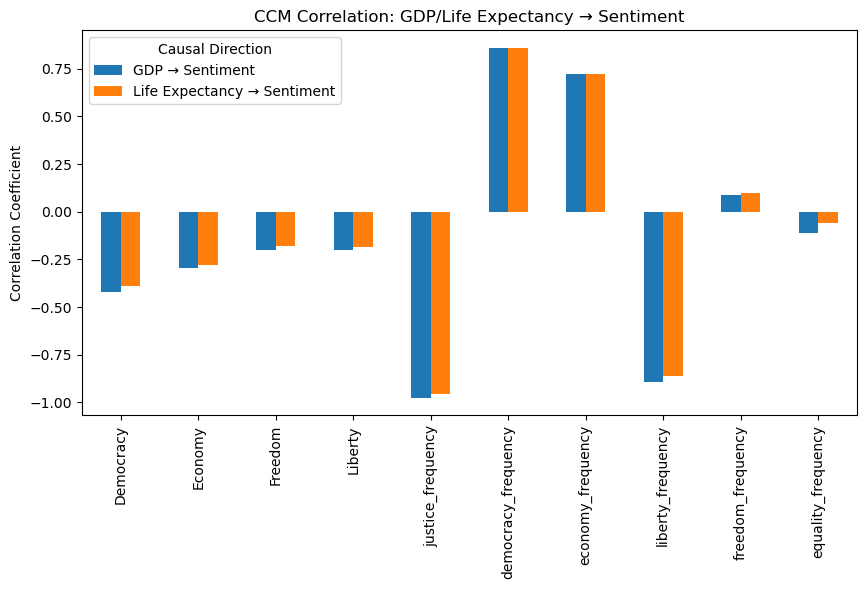

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests, adfuller, acf, pacf, q_stat
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import pairwise_distances
from scipy.integrate import solve_ivp

# Time-delay embedding
def time_delay_embedding(series, delay, dimension):
    n = len(series)
    embedded = np.zeros((n - (dimension - 1) * delay, dimension))
    for i in range(dimension):
        embedded[:, i] = series[i * delay:n - (dimension - 1 - i) * delay]
    return embedded

# Convergent Cross Mapping (CCM)
def cross_map(source, target, delay, dimension):
    embedded_target = time_delay_embedding(target, delay, dimension)
    predictions = []
    for i in range(len(embedded_target)):
        neighbors = np.argsort(np.linalg.norm(embedded_target - embedded_target[i], axis=1))[:dimension + 1]
        weights = 1 / (np.linalg.norm(embedded_target[neighbors] - embedded_target[i], axis=1) + 1e-10)
        weights /= np.sum(weights)
        prediction = np.sum(weights * source[neighbors])
        predictions.append(prediction)
    return predictions

# Load dataset

# Convert year to datetime and sort
df['year'] = pd.to_datetime(df['year'], format='%Y')
df = df.sort_values(by='year')

# Pivot table to structure data for time series analysis
df_pivot = df.pivot(index='year', columns='Topic', values='value').dropna()

# Function to perform ADF test for stationarity
def adf_test(series, title):
    result = adfuller(series.dropna())
    print(f'ADF Test for {title}: p-value = {result[1]}')
    return result[1] < 0.05  # Return True if stationary

# Function to test Granger causality
def granger_test(df, target, predictors, max_lag=5):
    test_results = {}
    for predictor in predictors:
        test = grangercausalitytests(df[[target, predictor]], max_lag, verbose=False)
        p_values = [round(test[i+1][0]['ssr_ftest'][1], 4) for i in range(max_lag)]
        test_results[predictor] = p_values
    return pd.DataFrame(test_results, index=[f'Lag {i+1}' for i in range(max_lag)])

# Function to test autocorrelation
def autocorrelation_tests(series, lags=20):
    acf_values = acf(series.dropna(), nlags=lags)
    pacf_values = pacf(series.dropna(), nlags=lags)
    q_stat_values, p_values = q_stat(acf_values[1:], len(series.dropna()))
    return pd.DataFrame({'ACF': acf_values, 'PACF': pacf_values, 'Ljung-Box p': np.append(np.nan, p_values)})

# Function to fit ARIMA model
def fit_arima(series, order=(1, 1, 1)):
    model = ARIMA(series.dropna(), order=order).fit()
    print(model.summary())
    return model

# Apply tests to each topic
for topic in df_pivot.columns:
    print(f"\n--- Analysis for {topic} ---")
    adf_test(df_pivot[topic], topic)
    print("Autocorrelation Results:")
    print(autocorrelation_tests(df_pivot[topic]))
    print("\nFitting ARIMA Model:")
    fit_arima(df_pivot[topic])

# Granger causality tests
gdp_life = df_pivot[['gdp_percap', 'Life_expectancy']]
granger_results = {}
for topic in df_pivot.columns:
    if topic not in ['gdp_percap', 'Life_expectancy']:
        print(f"\n--- Granger Causality for {topic} ---")
        granger_results[topic] = granger_test(df_pivot, topic, ['gdp_percap', 'Life_expectancy'])

granger_df = pd.concat(granger_results, axis=1)
print(granger_df)
granger_df.to_csv("granger_causality_results.csv")

# Apply CCM to each sentiment topic
ccm_results = {}
sentiment_topics = ['Democracy', 'Economy', 'Freedom', 'Liberty', 'justice_frequency', 'democracy_frequency', 'economy_frequency', 'liberty_frequency', 'freedom_frequency', 'equality_frequency']

gdp_series = df_pivot['gdp_percap'].values
life_series = df_pivot['Life_expectancy'].values

def compute_ccm(topic_series, reference_series, delay=10, dimension=3):
    predicted = cross_map(reference_series, topic_series, delay, dimension)
    min_length = min(len(topic_series) - 3, len(predicted))
    return np.corrcoef(topic_series[3:3 + min_length], predicted[:min_length])[0, 1]

for topic in sentiment_topics:
    if topic not in df_pivot.columns:
        continue
    print(f"\n--- CCM for {topic} ---")
    ccm_results[topic] = {
        "GDP → Sentiment": compute_ccm(df_pivot[topic].values, gdp_series),
        "Life Expectancy → Sentiment": compute_ccm(df_pivot[topic].values, life_series)
    }

# Convert CCM results to DataFrame
ccm_df = pd.DataFrame(ccm_results).T
print(ccm_df)
ccm_df.to_csv("ccm_results.csv")

# Plot CCM correlations
ccm_df.plot(kind='bar', figsize=(10, 5))
plt.title("CCM Correlation: GDP/Life Expectancy → Sentiment")
plt.ylabel("Correlation Coefficient")
plt.legend(title="Causal Direction")
plt.savefig("ccm_results.png")
plt.show()



--- Analysis for Democracy ---
ADF Test for Democracy: p-value = 1.2608396024770615e-11
Autocorrelation Results:
         ACF      PACF  Ljung-Box p
0   1.000000  1.000000          NaN
1   0.305005  0.307728     0.001018
2   0.160365  0.075729     0.001006
3   0.097808  0.034148     0.001873
4   0.153345  0.121647     0.001388
5   0.242042  0.187259     0.000153
6   0.049136 -0.105038     0.000330
7   0.095061  0.073645     0.000466
8  -0.000743 -0.074831     0.000975
9   0.046922  0.015677     0.001715
10  0.141882  0.122680     0.001245
11  0.068932  0.002986     0.001825
12  0.026263 -0.048822     0.003101
13 -0.064643 -0.068542     0.004348
14  0.060331  0.081954     0.006070
15  0.140979  0.106943     0.004193
16  0.076367  0.006211     0.005210
17 -0.037432 -0.113873     0.007622
18 -0.106695 -0.093741     0.007306
19 -0.072579 -0.087892     0.008875
20 -0.038981 -0.038793     0.012289

Fitting ARIMA Model:
                               SARIMAX Results                          

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequenc

                               SARIMAX Results                                
Dep. Variable:        Life_expectancy   No. Observations:                  113
Model:                 ARIMA(1, 1, 1)   Log Likelihood                  57.472
Date:                Sun, 09 Feb 2025   AIC                           -108.944
Time:                        15:21:00   BIC                           -100.788
Sample:                    01-01-1850   HQIC                          -105.635
                         - 01-01-1962                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9252      0.086     10.703      0.000       0.756       1.095
ma.L1          0.0337      0.818      0.041      0.967      -1.569       1.637
sigma2         0.0206      0.001     15.282      0.0

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to conv


--- Granger Causality for Economy ---

--- Granger Causality for Freedom ---

--- Granger Causality for Liberty ---

--- Granger Causality for democracy_frequency ---

--- Granger Causality for economy_frequency ---

--- Granger Causality for equality_frequency ---

--- Granger Causality for freedom_frequency ---

--- Granger Causality for justice_frequency ---

--- Granger Causality for liberty_frequency ---
       Democracy                    Economy                    Freedom  \
      gdp_percap Life_expectancy gdp_percap Life_expectancy gdp_percap   
Lag 1     0.0033          0.6245     0.1705          0.3716     0.0737   
Lag 2     0.9042          0.6336     0.2155          0.0708     0.9582   
Lag 3     0.1974          0.4170     0.3792          0.0617     0.5250   
Lag 4     0.0845          0.4052     0.3751          0.1255     0.3476   
Lag 5     0.1031          0.4791     0.5213          0.1293     0.4631   

                         Liberty                 democracy_frequenc

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since function

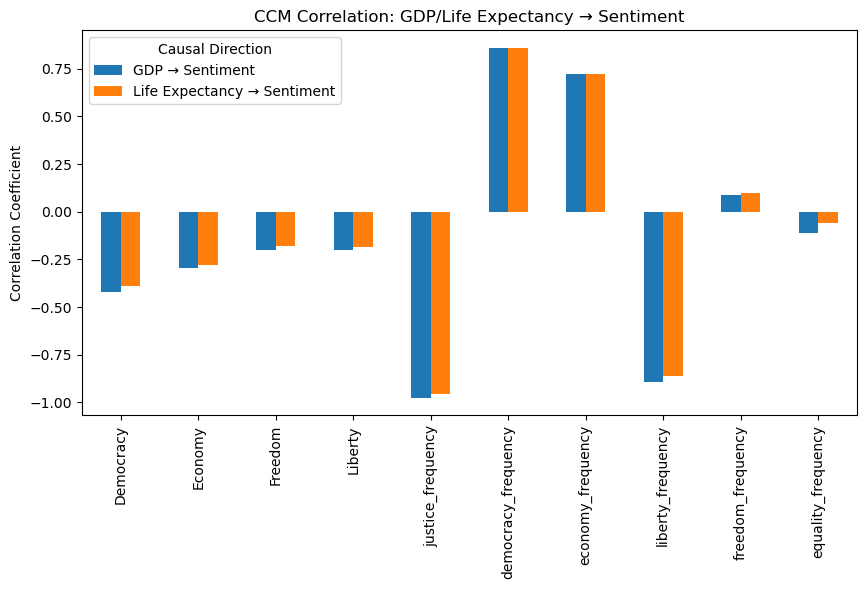

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests, adfuller, acf, pacf, q_stat
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import pairwise_distances
from scipy.integrate import solve_ivp

# Time-delay embedding
def time_delay_embedding(series, delay, dimension):
    n = len(series)
    embedded = np.zeros((n - (dimension - 1) * delay, dimension))
    for i in range(dimension):
        embedded[:, i] = series[i * delay:n - (dimension - 1 - i) * delay]
    return embedded

# Convergent Cross Mapping (CCM)
def cross_map(source, target, delay, dimension):
    embedded_target = time_delay_embedding(target, delay, dimension)
    predictions = []
    for i in range(len(embedded_target)):
        neighbors = np.argsort(np.linalg.norm(embedded_target - embedded_target[i], axis=1))[:dimension + 1]
        weights = 1 / (np.linalg.norm(embedded_target[neighbors] - embedded_target[i], axis=1) + 1e-10)
        weights /= np.sum(weights)
        prediction = np.sum(weights * source[neighbors])
        predictions.append(prediction)
    return predictions



# Function to perform ADF test for stationarity
def adf_test(series, title):
    result = adfuller(series.dropna())
    print(f'ADF Test for {title}: p-value = {result[1]}')
    return result[1] < 0.05  # Return True if stationary

# Function to test Granger causality
def granger_test(df, target, predictors, max_lag=5):
    test_results = {}
    for predictor in predictors:
        test = grangercausalitytests(df[[predictor, target]], max_lag, verbose=False)
        p_values = [round(test[i+1][0]['ssr_ftest'][1], 4) for i in range(max_lag)]
        test_results[predictor] = p_values
    return pd.DataFrame(test_results, index=[f'Lag {i+1}' for i in range(max_lag)])

# Function to test autocorrelation
def autocorrelation_tests(series, lags=20):
    acf_values = acf(series.dropna(), nlags=lags)
    pacf_values = pacf(series.dropna(), nlags=lags)
    q_stat_values, p_values = q_stat(acf_values[1:], len(series.dropna()))
    return pd.DataFrame({'ACF': acf_values, 'PACF': pacf_values, 'Ljung-Box p': np.append(np.nan, p_values)})

# Function to fit ARIMA model
def fit_arima(series, order=(1, 1, 1)):
    model = ARIMA(series.dropna(), order=order).fit()
    print(model.summary())
    return model

# Apply tests to each topic
for topic in df_pivot.columns:
    print(f"\n--- Analysis for {topic} ---")
    adf_test(df_pivot[topic], topic)
    print("Autocorrelation Results:")
    print(autocorrelation_tests(df_pivot[topic]))
    print("\nFitting ARIMA Model:")
    fit_arima(df_pivot[topic])

# Granger causality tests
gdp_life = df_pivot[['gdp_percap', 'Life_expectancy']].copy()

granger_results = {}
for topic in df_pivot.columns:
    if topic not in ['gdp_percap', 'Life_expectancy']:
        print(f"\n--- Granger Causality for {topic} ---")
        granger_results[topic] = granger_test(df_pivot, topic, ['gdp_percap', 'Life_expectancy'])

granger_df = pd.concat(granger_results, axis=1)
print(granger_df)
granger_df.to_csv("granger_causality_results.csv")

# Apply CCM to each sentiment topic
ccm_results = {}
sentiment_topics = ['Democracy', 'Economy', 'Freedom', 'Liberty', 'justice_frequency', 'democracy_frequency', 'economy_frequency', 'liberty_frequency', 'freedom_frequency', 'equality_frequency']

gdp_series = df_pivot['gdp_percap'].values
life_series = df_pivot['Life_expectancy'].values

def compute_ccm(topic_series, reference_series, delay=10, dimension=3):
    predicted = cross_map(reference_series, topic_series, delay, dimension)
    min_length = min(len(topic_series) - 3, len(predicted))
    return np.corrcoef(topic_series[3:3 + min_length], predicted[:min_length])[0, 1]

for topic in sentiment_topics:
    if topic not in df_pivot.columns:
        continue
    print(f"\n--- CCM for {topic} ---")
    ccm_results[topic] = {
        "GDP → Sentiment": compute_ccm(df_pivot[topic].values, gdp_series),
        "Life Expectancy → Sentiment": compute_ccm(df_pivot[topic].values, life_series)
    }

# Convert CCM results to DataFrame
ccm_df = pd.DataFrame(ccm_results).T
print(ccm_df)
ccm_df.to_csv("ccm_results.csv")

# Plot CCM correlations
ccm_df.plot(kind='bar', figsize=(10, 5))
plt.title("CCM Correlation: GDP/Life Expectancy → Sentiment")
plt.ylabel("Correlation Coefficient")
plt.legend(title="Causal Direction")
plt.savefig("ccm_results.png")
plt.show()



--- Analysis for Democracy ---
ADF Test for Democracy: p-value = 1.2608396024770615e-11
Autocorrelation Results:
         ACF      PACF  Ljung-Box p
0   1.000000  1.000000          NaN
1   0.305005  0.307728     0.001018
2   0.160365  0.075729     0.001006
3   0.097808  0.034148     0.001873
4   0.153345  0.121647     0.001388
5   0.242042  0.187259     0.000153
6   0.049136 -0.105038     0.000330
7   0.095061  0.073645     0.000466
8  -0.000743 -0.074831     0.000975
9   0.046922  0.015677     0.001715
10  0.141882  0.122680     0.001245
11  0.068932  0.002986     0.001825
12  0.026263 -0.048822     0.003101
13 -0.064643 -0.068542     0.004348
14  0.060331  0.081954     0.006070
15  0.140979  0.106943     0.004193
16  0.076367  0.006211     0.005210
17 -0.037432 -0.113873     0.007622
18 -0.106695 -0.093741     0.007306
19 -0.072579 -0.087892     0.008875
20 -0.038981 -0.038793     0.012289

Fitting ARIMA Model:
                               SARIMAX Results                          

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequenc

ADF Test for democracy_frequency: p-value = 0.928584004336814
Autocorrelation Results:
         ACF        PACF    Ljung-Box p
0   1.000000    1.000000            NaN
1   0.987468    0.996285   2.013695e-26
2   0.962345   -1.739431   7.748765e-49
3   0.926938   -0.757562   1.013329e-69
4   0.883774   -0.842122   8.869684e-89
5   0.836011   -3.758985  6.959280e-106
6   0.786142    1.267133  4.870259e-121
7   0.736783    0.652840  2.314439e-134
8   0.689516    0.643474  4.996609e-146
9   0.645346    1.064448  3.108453e-156
10  0.604413  -13.661059  3.639445e-165
11  0.567220   -0.951767  5.251773e-173
12  0.533766   -0.671202  6.377808e-180
13  0.504644   -0.995096  4.447407e-186
14  0.480684 -157.059305  1.198911e-191
15  0.461904    1.004462  8.722302e-197
16  0.447684    0.699576  1.275813e-201
17  0.437007    0.923836  3.018038e-206
18  0.427830    9.218763  1.054265e-210
19  0.418242   -1.091874  5.553279e-215
20  0.406710   -0.653603  4.902039e-219

Fitting ARIMA Model:
           

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to conv

                               SARIMAX Results                                
Dep. Variable:      freedom_frequency   No. Observations:                  113
Model:                 ARIMA(1, 1, 1)   Log Likelihood                1149.961
Date:                Sun, 09 Feb 2025   AIC                          -2293.921
Time:                        15:26:42   BIC                          -2285.766
Sample:                    01-01-1850   HQIC                         -2290.612
                         - 01-01-1962                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8653   4.85e-20   1.78e+19      0.000       0.865       0.865
ma.L1         -0.0839   4.11e-20  -2.04e+18      0.000      -0.084      -0.084
sigma2      2.135e-10   1.95e-10      1.095      0.2

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since function


--- Granger Causality for equality_frequency ---

--- Granger Causality for freedom_frequency ---

--- Granger Causality for justice_frequency ---

--- Granger Causality for liberty_frequency ---
       Democracy                    Economy                    Freedom  \
      gdp_percap Life_expectancy gdp_percap Life_expectancy gdp_percap   
Lag 1     0.0033          0.6245     0.1705          0.3716     0.0737   
Lag 2     0.9042          0.6336     0.2155          0.0708     0.9582   
Lag 3     0.1974          0.4170     0.3792          0.0617     0.5250   
Lag 4     0.0845          0.4052     0.3751          0.1255     0.3476   
Lag 5     0.1031          0.4791     0.5213          0.1293     0.4631   

                         Liberty                 democracy_frequency  \
      Life_expectancy gdp_percap Life_expectancy          gdp_percap   
Lag 1          0.9027     0.0341          0.7873              0.0000   
Lag 2          0.3069     0.3136          0.1303              0.3077

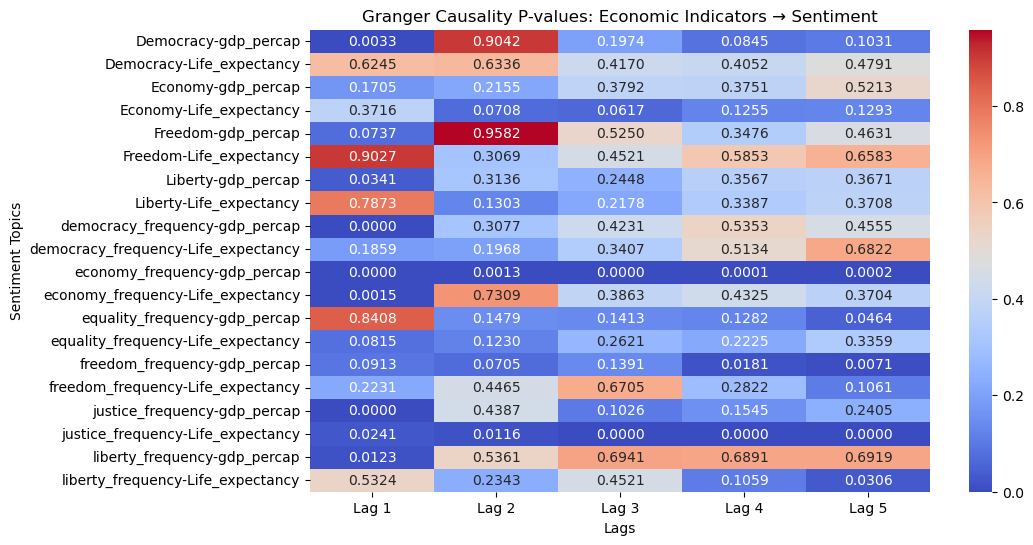


--- CCM for Democracy ---

--- CCM for Economy ---

--- CCM for Freedom ---

--- CCM for Liberty ---

--- CCM for justice_frequency ---

--- CCM for democracy_frequency ---

--- CCM for economy_frequency ---

--- CCM for liberty_frequency ---

--- CCM for freedom_frequency ---

--- CCM for equality_frequency ---
                     GDP → Sentiment  Life Expectancy → Sentiment
Democracy                  -0.419329                    -0.387429
Economy                    -0.295499                    -0.282305
Freedom                    -0.199807                    -0.181674
Liberty                    -0.201303                    -0.183733
justice_frequency          -0.976434                    -0.958613
democracy_frequency         0.859876                     0.859432
economy_frequency           0.720035                     0.723271
liberty_frequency          -0.894702                    -0.860686
freedom_frequency           0.088315                     0.099023
equality_frequency       

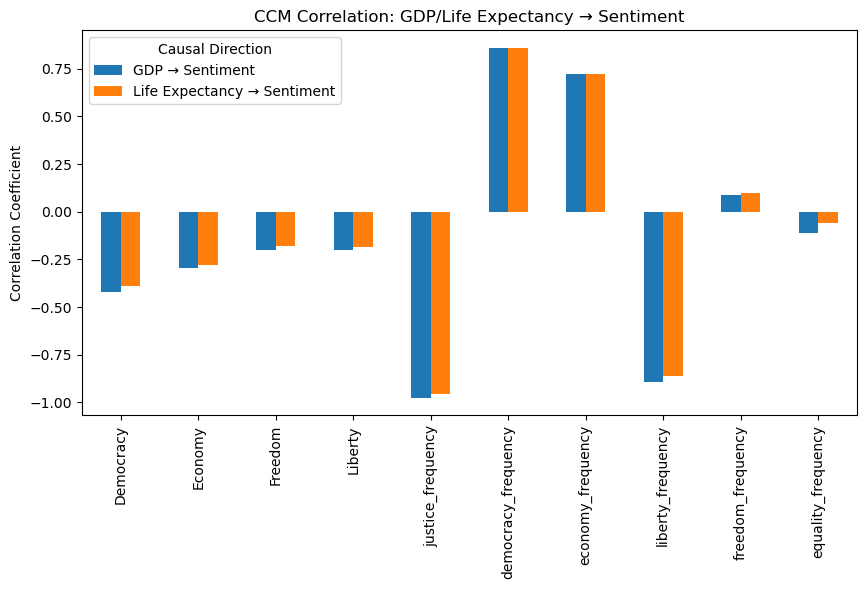

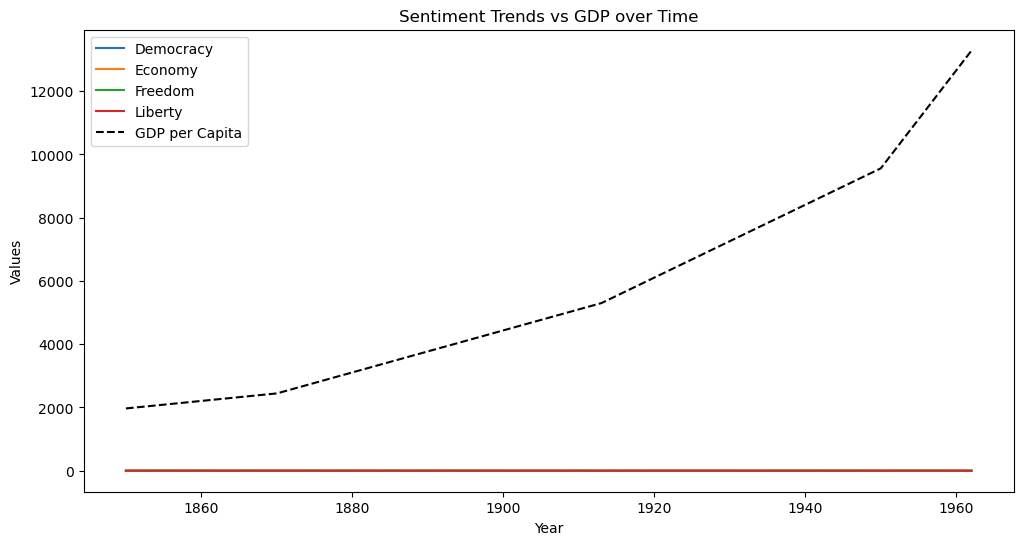

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests, adfuller, acf, pacf, q_stat
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import pairwise_distances
from scipy.integrate import solve_ivp

# Time-delay embedding
def time_delay_embedding(series, delay, dimension):
    n = len(series)
    embedded = np.zeros((n - (dimension - 1) * delay, dimension))
    for i in range(dimension):
        embedded[:, i] = series[i * delay:n - (dimension - 1 - i) * delay]
    return embedded

# Convergent Cross Mapping (CCM)
def cross_map(source, target, delay, dimension):
    embedded_target = time_delay_embedding(target, delay, dimension)
    predictions = []
    for i in range(len(embedded_target)):
        neighbors = np.argsort(np.linalg.norm(embedded_target - embedded_target[i], axis=1))[:dimension + 1]
        weights = 1 / (np.linalg.norm(embedded_target[neighbors] - embedded_target[i], axis=1) + 1e-10)
        weights /= np.sum(weights)
        prediction = np.sum(weights * source[neighbors])
        predictions.append(prediction)
    return predictions



# Function to perform ADF test for stationarity
def adf_test(series, title):
    result = adfuller(series.dropna())
    print(f'ADF Test for {title}: p-value = {result[1]}')
    return result[1] < 0.05  # Return True if stationary

# Function to test Granger causality
def granger_test(df, target, predictors, max_lag=5):
    test_results = {}
    for predictor in predictors:
        test = grangercausalitytests(df[[predictor, target]], max_lag, verbose=False)
        p_values = [round(test[i+1][0]['ssr_ftest'][1], 4) for i in range(max_lag)]
        test_results[predictor] = p_values
    return pd.DataFrame(test_results, index=[f'Lag {i+1}' for i in range(max_lag)])

# Function to test autocorrelation
def autocorrelation_tests(series, lags=20):
    acf_values = acf(series.dropna(), nlags=lags)
    pacf_values = pacf(series.dropna(), nlags=lags)
    q_stat_values, p_values = q_stat(acf_values[1:], len(series.dropna()))
    return pd.DataFrame({'ACF': acf_values, 'PACF': pacf_values, 'Ljung-Box p': np.append(np.nan, p_values)})

# Function to fit ARIMA model
def fit_arima(series, order=(1, 1, 1)):
    model = ARIMA(series.dropna(), order=order).fit()
    print(model.summary())
    return model

# Apply tests to each topic
for topic in df_pivot.columns:
    print(f"\n--- Analysis for {topic} ---")
    adf_test(df_pivot[topic], topic)
    print("Autocorrelation Results:")
    print(autocorrelation_tests(df_pivot[topic]))
    print("\nFitting ARIMA Model:")
    fit_arima(df_pivot[topic])

# Granger causality tests
gdp_life = df_pivot[['gdp_percap', 'Life_expectancy']].copy()

granger_results = {}
for topic in df_pivot.columns:
    if topic not in ['gdp_percap', 'Life_expectancy']:
        print(f"\n--- Granger Causality for {topic} ---")
        granger_results[topic] = granger_test(df_pivot, topic, ['gdp_percap', 'Life_expectancy'])

granger_df = pd.concat(granger_results, axis=1)
print(granger_df)
granger_df.to_csv("granger_causality_results.csv")

# Visualization: Heatmap of Granger Causality P-values
plt.figure(figsize=(10, 6))
sns.heatmap(granger_df.T, annot=True, cmap="coolwarm", fmt=".4f")
plt.title("Granger Causality P-values: Economic Indicators → Sentiment")
plt.ylabel("Sentiment Topics")
plt.xlabel("Lags")
plt.savefig("granger_causality_heatmap.png")
plt.show()

# Apply CCM to each sentiment topic
ccm_results = {}
sentiment_topics = ['Democracy', 'Economy', 'Freedom', 'Liberty', 'justice_frequency', 'democracy_frequency', 'economy_frequency', 'liberty_frequency', 'freedom_frequency', 'equality_frequency']

gdp_series = df_pivot['gdp_percap'].values
life_series = df_pivot['Life_expectancy'].values

def compute_ccm(topic_series, reference_series, delay=10, dimension=3):
    predicted = cross_map(reference_series, topic_series, delay, dimension)
    min_length = min(len(topic_series) - 3, len(predicted))
    return np.corrcoef(topic_series[3:3 + min_length], predicted[:min_length])[0, 1]

for topic in sentiment_topics:
    if topic not in df_pivot.columns:
        continue
    print(f"\n--- CCM for {topic} ---")
    ccm_results[topic] = {
        "GDP → Sentiment": compute_ccm(df_pivot[topic].values, gdp_series),
        "Life Expectancy → Sentiment": compute_ccm(df_pivot[topic].values, life_series)
    }

# Convert CCM results to DataFrame
ccm_df = pd.DataFrame(ccm_results).T
print(ccm_df)
ccm_df.to_csv("ccm_results.csv")

# Visualization: CCM Correlation Bar Chart
ccm_df.plot(kind='bar', figsize=(10, 5))
plt.title("CCM Correlation: GDP/Life Expectancy → Sentiment")
plt.ylabel("Correlation Coefficient")
plt.legend(title="Causal Direction")
plt.savefig("ccm_results.png")
plt.show()

# Time Series Plot for Sentiments & GDP
plt.figure(figsize=(12, 6))
for topic in ['Democracy', 'Economy', 'Freedom', 'Liberty']:
    if topic in df_pivot.columns:
        plt.plot(df_pivot.index, df_pivot[topic], label=topic)
plt.plot(df_pivot.index, df_pivot['gdp_percap'], label='GDP per Capita', linestyle='dashed', color='black')
plt.title("Sentiment Trends vs GDP over Time")
plt.xlabel("Year")
plt.ylabel("Values")
plt.legend()
plt.savefig("sentiment_vs_gdp.png")
plt.show()
